# __________
# __________
# __________

# READ ANGLE NLL

In [57]:
import numpy as np
from ctypes import Union, c_float, c_ushort
import matplotlib.pyplot as plt



# ---- Union equivalent to NonLinLoc TakeOffAngles ----
class TakeOffAngles(Union):
    _fields_ = [
        ("fval", c_float),
        ("ival", c_ushort * 2),
    ]


# ---- Read header file ----
def read_hdr(hdr_file):
    with open(hdr_file, "r") as f:
        first_line = f.readline().split()

    nx = int(first_line[0])
    ny = int(first_line[1])
    nz = int(first_line[2])
    grid_type = first_line[9]

    return nx, ny, nz, grid_type


# ---- Read ANGLE buffer ----
def read_angle_buf(buf_file, nx, ny, nz):

    nitems = nx * ny * nz

    # read raw floats
    buf = np.fromfile(buf_file, dtype=np.float32, count=nitems)

    if len(buf) != nitems:
        raise ValueError("Incorrect number of values in buffer, not matching header grid.")

    # reinterpret floats using union
    angles = (TakeOffAngles * nitems)()

    for i, val in enumerate(buf):
        angles[i].fval = val

    azimuth = np.array(
        [a.ival[1] / 10.0 for a in angles]
    ).reshape(nx, ny, nz)

    dip = np.array(
        [(a.ival[0] // 16) / 10.0 for a in angles]
    ).reshape(nx, ny, nz)

    quality = np.array(
        [a.ival[0] % 16 for a in angles]
    ).reshape(nx, ny, nz)

    # apply NonLinLoc convention
    azimuth[quality == 0] = np.nan
    dip[quality == 0] = np.nan

    return azimuth, dip, quality



# ---- Example usage ----
if __name__ == "__main__":

    basename = "/Users/giaco/UNI/PhD_CODE/GIT/DAS_synthetic_eikonal/3D/NLL/FLEGREI_0/nll_grid/time.P.CAAM.angle"

    hdr_file = basename + ".hdr"
    buf_file = basename + ".buf"

    nx, ny, nz, grid_type = read_hdr(hdr_file)

    if grid_type != "ANGLE":
        raise ValueError("Grid is not ANGLE type")

    az, dip, qual = read_angle_buf(buf_file, nx, ny, nz)

    print("Azimuth shape:", az.shape)
    print("Dip shape:", dip.shape)
    print("Quality shape:", qual.shape)


Azimuth shape: (151, 151, 61)
Dip shape: (151, 151, 61)
Quality shape: (151, 151, 61)


1.8
359.8


Quality values: [ 0  1  2  3  4  5  6  7  8  9 10]
Numero quality=0: 81003
Percentuale NaN: 5.823946461939763


0 81003
1 1
2 1
3 4
4 1
5 1
6 29
7 4714
8 84695
9 866054
10 354358


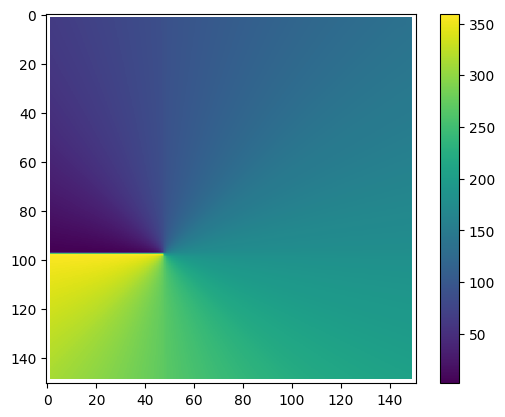

In [22]:
# tests

print(np.nanmin(az))
print(np.nanmax(az))
plt.imshow(az[:,:,30])
plt.colorbar()

print('\n')
print("Quality values:", np.unique(qual))
print("Numero quality=0:", np.sum(qual == 0))
print("Percentuale NaN:", np.sum(np.isnan(az)) / az.size * 100)

print('\n')
for q in np.unique(qual):
    print(q, np.sum(qual == q))


# _________________
# _________________
# _________________


### Decimate fiber

In [3]:
filepath='/Users/giaco/UNI/PhD_CODE/GIT/DAS_3D_synth_eikonal/FIBER_GEOMETRY/flegrei_das_geom_all.txt'
fiber_geometry = []
f = open(filepath, "r")
lines = f.readlines()
f.close()
for line in lines[1:]:  # skip header
    ch_number, lat, lon, depth = line.split()
    fiber_geometry.append([str(ch_number), float(lat), float(lon), float(depth)])
# total number of channels
ns_ch=len(fiber_geometry)
print("Total number of channels:", ns_ch)

Total number of channels: 4272


In [4]:
i=0

ns_ch_new=101       #change
ratio = int(ns_ch / ns_ch_new)
ratio


42

### Catalogue

In [ ]:
newf=[]
network='DAS'
for ch in fiber_geometry:
    if i%ratio==0:
        number= str(ch[0])
        lat=ch[1] 
        lon=ch[2]
        elev=ch[3] 
        newf.append([network, number, lat, lon, elev])
    i+=1
    
with open('/Users/giaco/UNI/PhD_CODE/GIT/DAS_3D_synth_eikonal/FIBER_GEOMETRY/flegrei_das_geom_101ch.txt', 'w') as f:
    f.write("Network_name Station_name Latitude Longitude Elevation_km\n")
    for ch in newf:
        f.write(f"{ch[0]} {ch[1]} {ch[2]} {ch[3]} {ch[4]}\n")
    f.close()

### NLL Grid2Time

In [6]:
with open('/Users/giaco/UNI/PhD_CODE/GIT/DAS_3D_synth_eikonal/FIBER_GEOMETRY/flegrei_das_geom_101ch_nll.txt', 'w') as nll_f:
    for ch in newf:
        nll_f.write(f"GTSRCE {ch[1]} LATLON {ch[2]} {ch[3]} 0. {ch[4]}\n")
    nll_f.close()

### NLL Header

In [7]:
with open('/Users/giaco/UNI/PhD_CODE/GIT/DAS_3D_synth_eikonal/FIBER_GEOMETRY/flegrei_das_geom_101ch_nll_header.txt', 'w') as nll_f:
    for ch in newf:
        nll_f.write(f"{ch[1]} {ch[2]} {ch[3]} {ch[4]}\n")
    nll_f.close()